# Model Results Visualisation

This notebook consolidates the exported artifacts under `reports/` into static, report-ready figures.

Notes:
- Logistic and XGBoost basecase outputs are validation results.
- PatchTST forecasting outputs are test results.
- LSTM outputs are reported separately because the longest horizon is `30days`, not `20days`.
- Cross-validation diagnostics are shown separately from the basecase forecasting views.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists() or (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from notebook location")


ROOT = find_repo_root(Path.cwd())
REPORTS_DIR = ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "model_results_visualisation"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MODEL_COLORS = {
    "Logistic": "#355C7D",
    "XGBoost": "#C06C84",
    "PatchTST": "#F67280",
    "LSTM": "#6C5B7B",
}
HORIZON_ORDER = ["1day", "5days", "20days", "30days"]


def save_current_figure(name: str) -> Path:
    path = FIGURES_DIR / name
    plt.savefig(path)
    return path


In [2]:
def load_prediction_metrics(path: Path, model_name: str, split: str, horizon: str) -> dict:
    df = pd.read_csv(path)
    return {
        "model": model_name,
        "split": split,
        "horizon": horizon,
        "accuracy": accuracy_score(df["y_true"], df["y_pred"]),
        "precision": precision_score(df["y_true"], df["y_pred"], zero_division=0),
        "recall": recall_score(df["y_true"], df["y_pred"], zero_division=0),
        "f1_score": f1_score(df["y_true"], df["y_pred"], zero_division=0),
        "roc_auc": roc_auc_score(df["y_true"], df["y_pred_prob"]),
    }


def load_basecase_metrics() -> pd.DataFrame:
    records = []
    logistic_root = REPORTS_DIR / "trained_logistic"
    xgboost_root = REPORTS_DIR / "trained_xgboost"
    patchtst_root = REPORTS_DIR / "trained_patchtst"

    for horizon in ["1day", "5days", "20days"]:
        records.append(
            load_prediction_metrics(
                logistic_root / f"basecase_{horizon}" / "predictions.csv",
                model_name="Logistic",
                split="validation",
                horizon=horizon,
            )
        )
        records.append(
            load_prediction_metrics(
                xgboost_root / f"basecase_{horizon}" / "predictions.csv",
                model_name="XGBoost",
                split="validation",
                horizon=horizon,
            )
        )

    patchtst_map = {
        "1day": patchtst_root / "results_lag_1" / "predictions.csv",
        "5days": patchtst_root / "results_lag_5" / "predictions.csv",
        "20days": patchtst_root / "results_lag_20" / "predictions.csv",
    }
    for horizon, path in patchtst_map.items():
        records.append(
            load_prediction_metrics(
                path,
                model_name="PatchTST",
                split="test",
                horizon=horizon,
            )
        )

    df = pd.DataFrame(records)
    df["horizon"] = pd.Categorical(df["horizon"], categories=HORIZON_ORDER, ordered=True)
    return df.sort_values(["horizon", "model"]).reset_index(drop=True)


def load_basecase_predictions(horizon: str) -> pd.DataFrame:
    frames = []
    specs = [
        ("Logistic", "validation", REPORTS_DIR / "trained_logistic" / f"basecase_{horizon}" / "predictions.csv"),
        ("XGBoost", "validation", REPORTS_DIR / "trained_xgboost" / f"basecase_{horizon}" / "predictions.csv"),
    ]
    patchtst_lookup = {
        "1day": REPORTS_DIR / "trained_patchtst" / "results_lag_1" / "predictions.csv",
        "5days": REPORTS_DIR / "trained_patchtst" / "results_lag_5" / "predictions.csv",
        "20days": REPORTS_DIR / "trained_patchtst" / "results_lag_20" / "predictions.csv",
    }
    specs.append(("PatchTST", "test", patchtst_lookup[horizon]))

    for model_name, split, path in specs:
        df = pd.read_csv(path)
        df["Date"] = pd.to_datetime(df["Date"])
        df["model"] = model_name
        df["split"] = split
        df["horizon"] = horizon
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def load_cross_validation_results():
    test_records = []
    fold_records = []
    for model_name, folder in [("Logistic", "trained_logistic"), ("XGBoost", "trained_xgboost")]:
        test_path = REPORTS_DIR / folder / "cross_validation" / "test_metrics.csv"
        cv_path = REPORTS_DIR / folder / "cross_validation" / "cv_summary.csv"

        test_df = pd.read_csv(test_path).rename(columns={"best_threshold": "threshold"})
        test_df["model"] = model_name
        test_records.append(test_df)

        cv_df = pd.read_csv(cv_path)
        cv_df["model"] = model_name
        cv_df["row_type"] = "fold"
        if len(cv_df) >= 2:
            cv_df.loc[cv_df.index[-2], "row_type"] = "mean"
            cv_df.loc[cv_df.index[-1], "row_type"] = "std"
        fold_records.append(cv_df)

    test_results = pd.concat(test_records, ignore_index=True)
    cv_results = pd.concat(fold_records, ignore_index=True)
    return test_results, cv_results


def load_lstm_results():
    records = []
    cv_records = []
    for lag, horizon in [(1, "1day"), (5, "5days"), (30, "30days")]:
        test_path = REPORTS_DIR / "trained_ltsm" / f"results_lag_{lag}" / "test_metrics.csv"
        cv_path = REPORTS_DIR / "trained_ltsm" / f"results_lag_{lag}" / "cv_summary.csv"

        test_df = pd.read_csv(test_path).rename(columns={"Unnamed: 0": "split_name"})
        row = test_df.iloc[0].to_dict()
        row["model"] = "LSTM"
        row["split"] = "test"
        row["horizon"] = horizon
        records.append(row)

        cv_df = pd.read_csv(cv_path).rename(columns={"Unnamed: 0": "fold"})
        cv_df["model"] = "LSTM"
        cv_df["horizon"] = horizon
        cv_records.append(cv_df)

    lstm_test = pd.DataFrame(records)
    lstm_test["horizon"] = pd.Categorical(lstm_test["horizon"], categories=HORIZON_ORDER, ordered=True)
    lstm_cv = pd.concat(cv_records, ignore_index=True)
    return lstm_test.sort_values("horizon").reset_index(drop=True), lstm_cv


def load_training_curves():
    xgboost_frames = []
    for horizon in ["1day", "5days", "20days"]:
        path = REPORTS_DIR / "trained_xgboost" / f"basecase_{horizon}" / "learning_curve.csv"
        df = pd.read_csv(path)
        df["model"] = "XGBoost"
        df["horizon"] = horizon
        xgboost_frames.append(df)

    patchtst_frames = []
    lag_map = {"1day": "results_lag_1", "5days": "results_lag_5", "20days": "results_lag_20"}
    for horizon, folder in lag_map.items():
        path = REPORTS_DIR / "trained_patchtst" / folder / "training_history.csv"
        df = pd.read_csv(path)
        df["model"] = "PatchTST"
        df["horizon"] = horizon
        patchtst_frames.append(df)

    return pd.concat(xgboost_frames, ignore_index=True), pd.concat(patchtst_frames, ignore_index=True)


def plot_image_grid(image_paths, titles, ncols=3, figsize=(15, 12)):
    n_images = len(image_paths)
    nrows = math.ceil(n_images / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for ax, path, title in zip(axes, image_paths, titles):
        if Path(path).exists():
            img = mpimg.imread(path)
            ax.imshow(img)
            ax.set_title(title)
            ax.axis("off")
        else:
            ax.text(0.5, 0.5, f"Missing\n{Path(path).name}", ha="center", va="center")
            ax.set_title(title)
            ax.axis("off")
    for ax in axes[n_images:]:
        ax.axis("off")
    return fig


def draw_confusion_artifact(ax, title: str, csv_path: Path | None = None, image_path: Path | None = None):
    if csv_path is not None and csv_path.exists():
        df = pd.read_csv(csv_path, index_col=0)
        sns.heatmap(df, annot=True, fmt="g", cmap="Blues", cbar=False, ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")
        return

    if image_path is not None and image_path.exists():
        img = mpimg.imread(image_path)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
        return

    ax.text(0.5, 0.5, "Missing artifact", ha="center", va="center")
    ax.set_title(title)
    ax.axis("off")


basecase_metrics = load_basecase_metrics()
crossval_test, crossval_folds = load_cross_validation_results()
lstm_test, lstm_cv = load_lstm_results()
xgb_learning_curves, patchtst_training = load_training_curves()

display(basecase_metrics)
display(crossval_test)
display(lstm_test[["horizon", "accuracy", "roc_auc", "precision", "recall"]])


,model,split,horizon,accuracy,precision,recall,f1_score,roc_auc
0,Logistic,validation,1day,0.775476,0.929730,0.758545,0.835458,0.848045
1,PatchTST,test,1day,0.722411,0.932318,0.657518,0.771169,0.855724
2,XGBoost,validation,1day,0.879867,0.950355,0.886439,0.917285,0.948964
3,Logistic,validation,5days,0.694030,0.935170,0.636865,0.757715,0.818131
4,PatchTST,test,5days,0.736063,0.902711,0.700495,0.788850,0.840605
5,XGBoost,validation,5days,0.831675,0.942138,0.826711,0.880658,0.909698
6,Logistic,validation,20days,0.248339,0.000000,0.000000,0.000000,0.603897
7,PatchTST,test,20days,0.491477,0.832714,0.312849,0.454822,0.686428
8,XGBoost,validation,20days,0.397841,0.797342,0.265487,0.398340,0.644008


,model,target,accuracy,roc_auc,precision,recall,threshold
0,Logistic,regime_binary,0.671914,0.722936,0.849926,0.659746,0.345728
1,XGBoost,regime_binary,0.673571,0.571960,0.773410,0.771626,0.437452


,horizon,accuracy,roc_auc,precision,recall
0,1day,0.596801,0.714047,0.989390,0.439858
1,5days,0.581650,0.690219,0.951157,0.436321
2,30days,0.678209,0.601289,0.770128,0.781991


## Basecase Forecasting Metrics

This view compares the standardized exports for the three forecasting families that already provide horizon-specific prediction files:
Logistic, XGBoost, and PatchTST.

Because the exported evaluation split is not identical across every model family, the plot keeps the split in the legend labels.


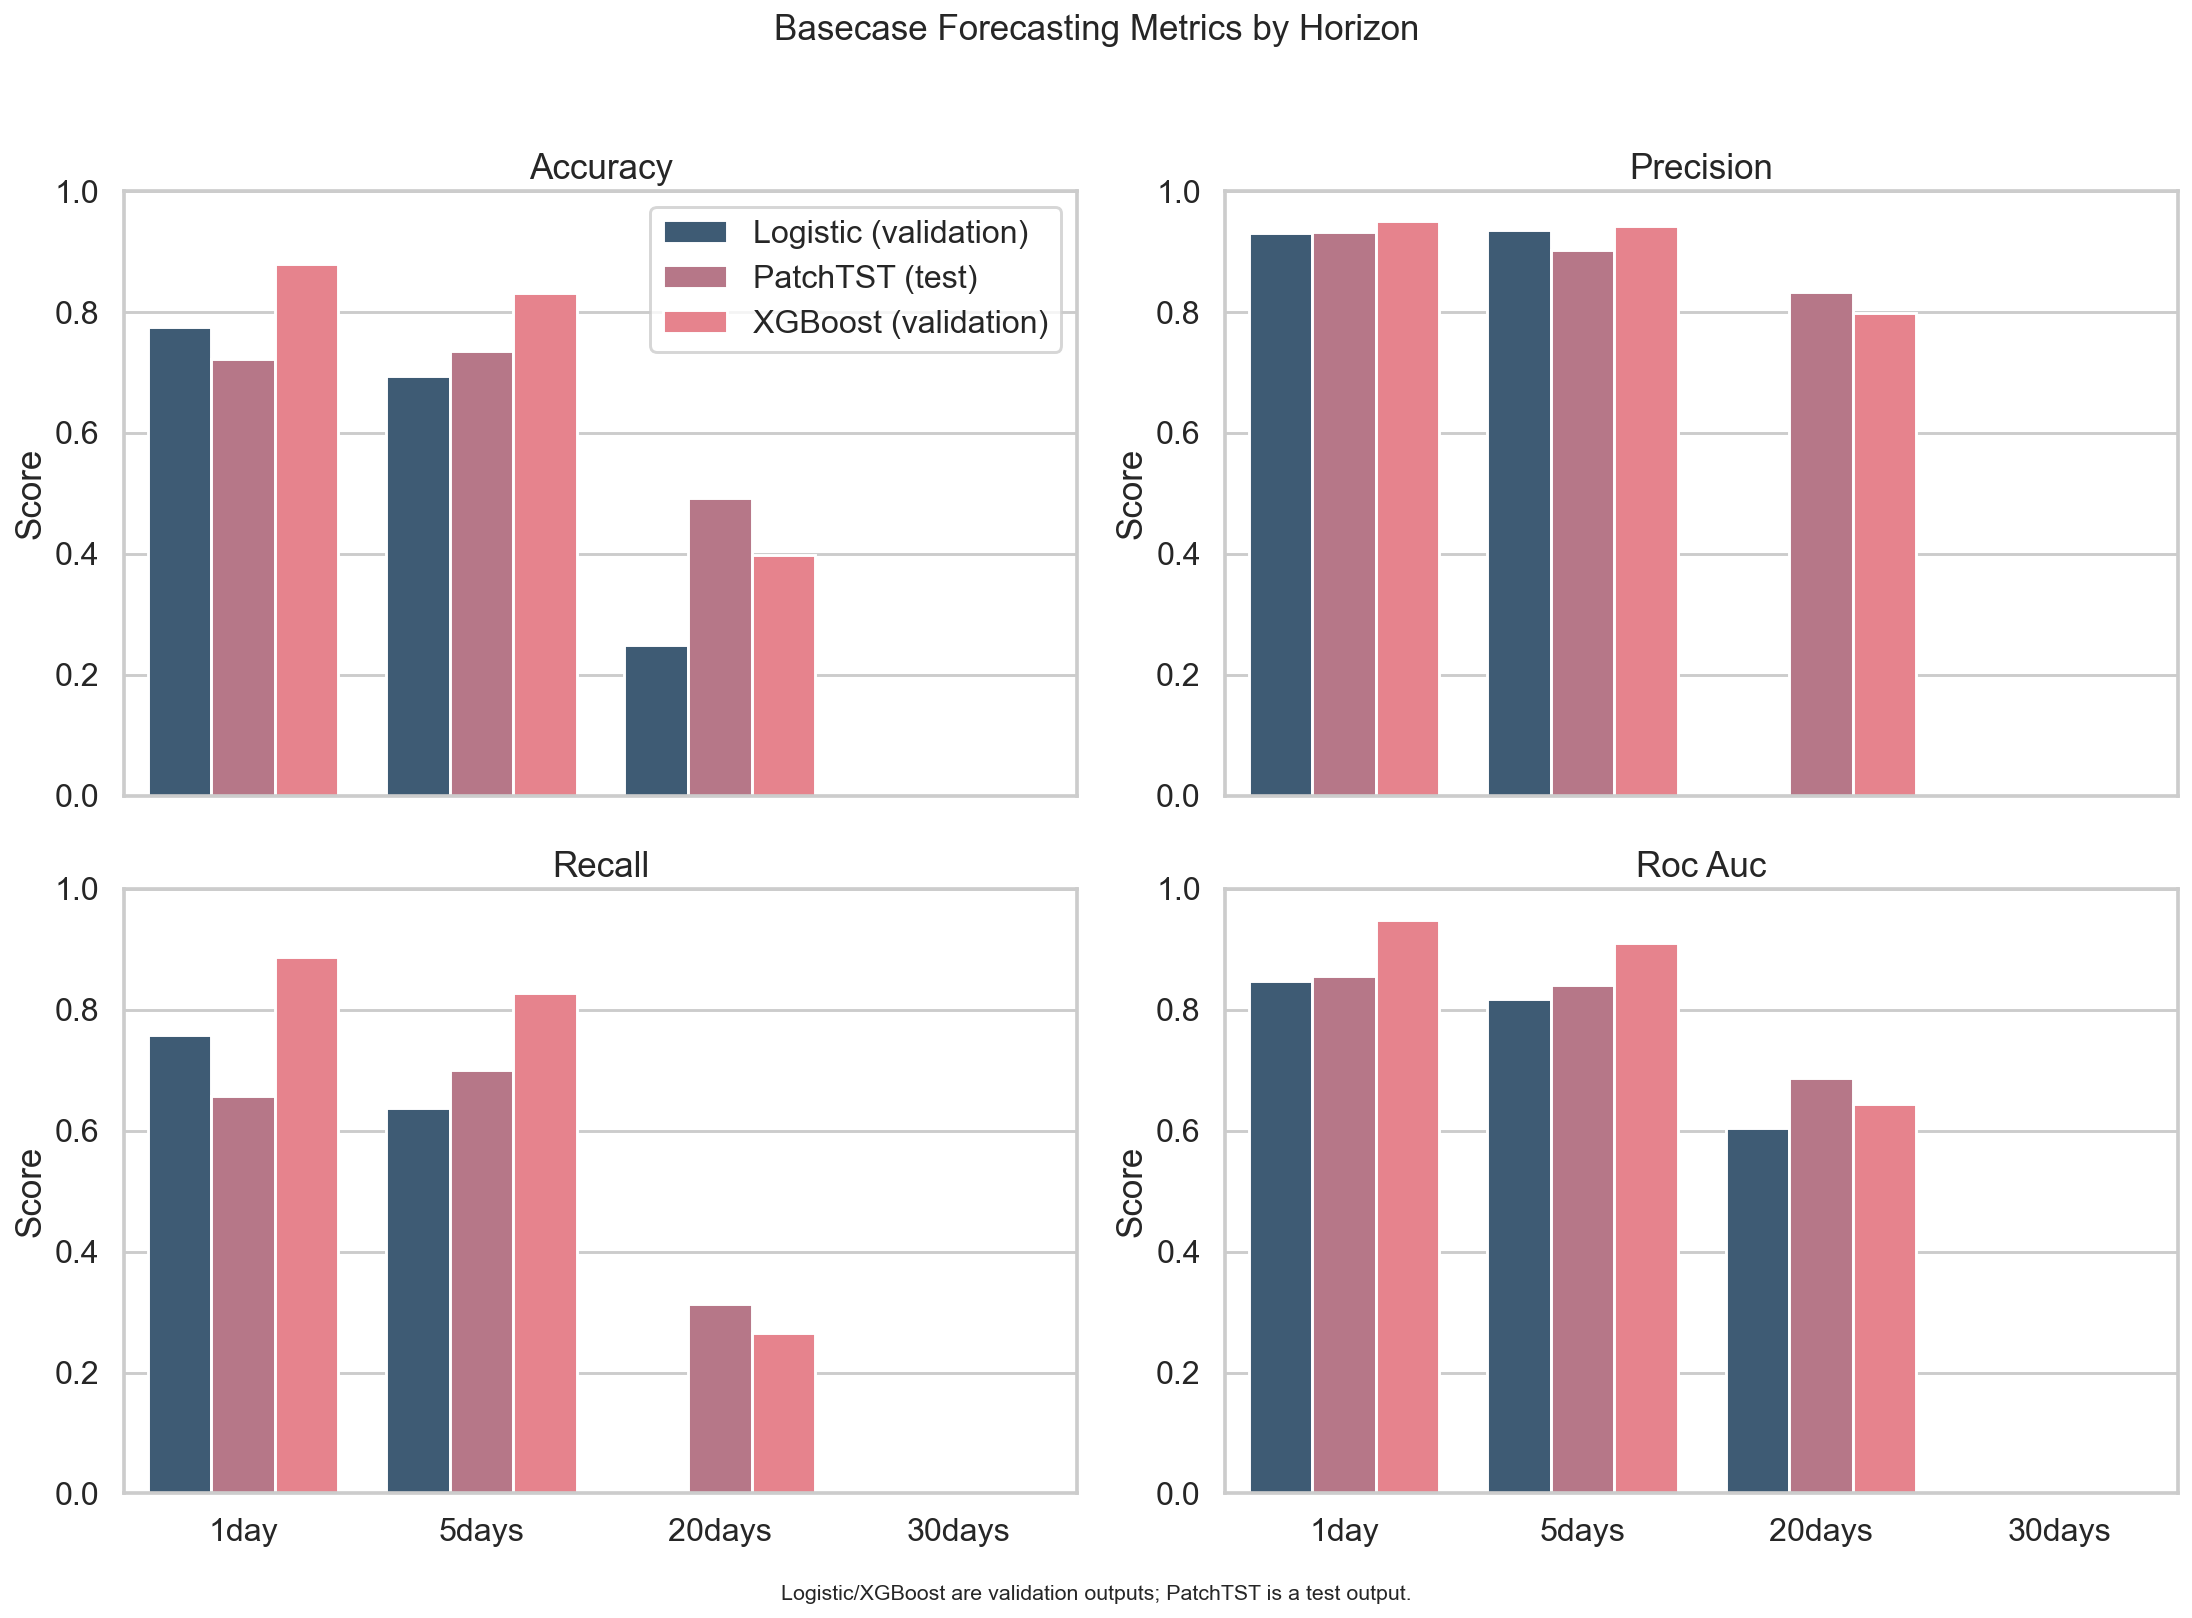

In [3]:
plot_df = basecase_metrics.copy()
plot_df["label"] = plot_df["model"] + " (" + plot_df["split"] + ")"
metric_order = ["accuracy", "precision", "recall", "roc_auc"]
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True)

for ax, metric in zip(axes.flat, metric_order):
    sns.barplot(
        data=plot_df,
        x="horizon",
        y=metric,
        hue="label",
        palette=["#355C7D", "#C06C84", "#F67280"],
        ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    if ax is axes.flat[0]:
        ax.legend(title="")
    else:
        ax.get_legend().remove()

fig.suptitle("Basecase Forecasting Metrics by Horizon", y=1.02, fontsize=18)
fig.text(0.5, -0.01, "Logistic/XGBoost are validation outputs; PatchTST is a test output.", ha="center", fontsize=11)
plt.tight_layout()
save_current_figure("basecase_forecasting_metrics.png")
plt.show()


In [4]:
summary_table = (
    basecase_metrics[["model", "split", "horizon", "accuracy", "precision", "recall", "f1_score", "roc_auc"]]
    .sort_values(["horizon", "model"])
    .reset_index(drop=True)
)
display(summary_table.style.format({col: "{:.3f}" for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]}))


,model,split,horizon,accuracy,precision,recall,f1_score,roc_auc
0,Logistic,validation,1day,0.775,0.930,0.759,0.835,0.848
1,PatchTST,test,1day,0.722,0.932,0.658,0.771,0.856
2,XGBoost,validation,1day,0.880,0.950,0.886,0.917,0.949
3,Logistic,validation,5days,0.694,0.935,0.637,0.758,0.818
4,PatchTST,test,5days,0.736,0.903,0.700,0.789,0.841
5,XGBoost,validation,5days,0.832,0.942,0.827,0.881,0.910
6,Logistic,validation,20days,0.248,0.000,0.000,0.000,0.604
7,PatchTST,test,20days,0.491,0.833,0.313,0.455,0.686
8,XGBoost,validation,20days,0.398,0.797,0.265,0.398,0.644


## 1-Day Prediction Probability Timelines

These charts make it easier to inspect calibration and regime flips over time than the saved single-model PNGs alone.


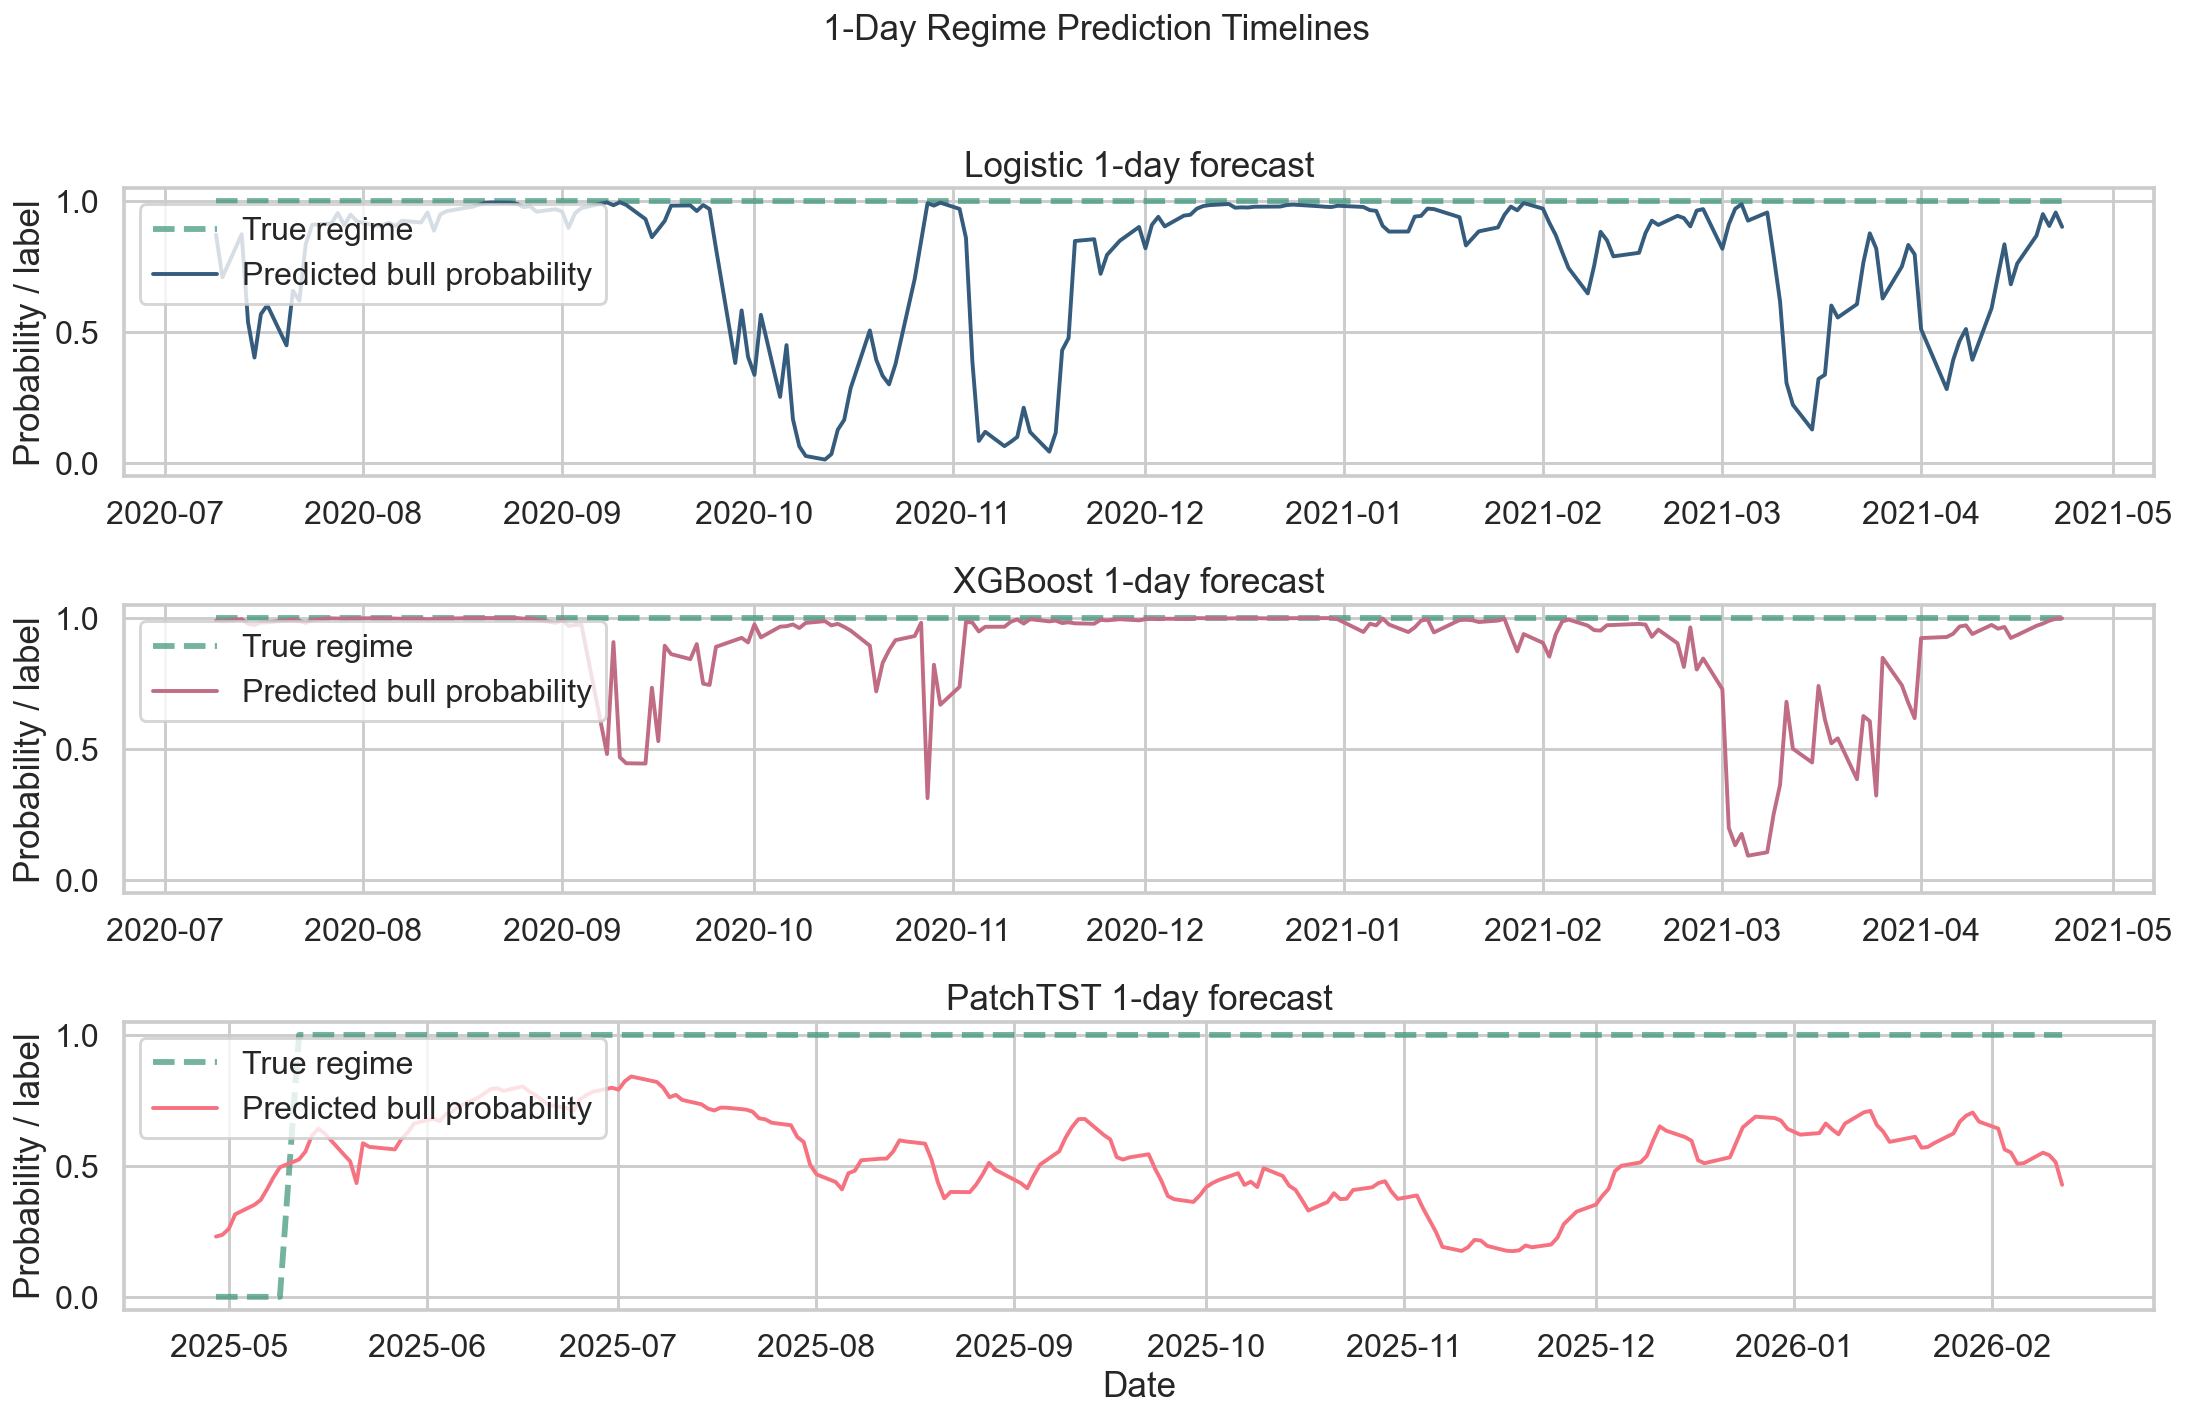

In [21]:
pred_1d = load_basecase_predictions("1day")
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=False)

for ax, model_name in zip(axes, ["Logistic", "XGBoost", "PatchTST"]):
    df = pred_1d[pred_1d["model"] == model_name].sort_values("Date").tail(200)
    ax.plot(df["Date"], df["y_true"], color="#389378", linestyle="--", linewidth=3, alpha=0.7, label="True regime")
    ax.plot(df["Date"], df["y_pred_prob"], color=MODEL_COLORS[model_name], linewidth=2, label="Predicted bull probability")
    # ax.axhline(0.5, color="#888888", linestyle="--", linewidth=1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{model_name} 1-day forecast")
    ax.set_ylabel("Probability / label")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("Date")
fig.suptitle("1-Day Regime Prediction Timelines", y=1.02, fontsize=18)
plt.tight_layout()
save_current_figure("prediction_timelines_1day.png")
plt.show()


## Cross-Validation Benchmarks

These are the standardized exports from `prediction_crossValidation.ipynb`, shown separately from the basecase horizon notebooks.


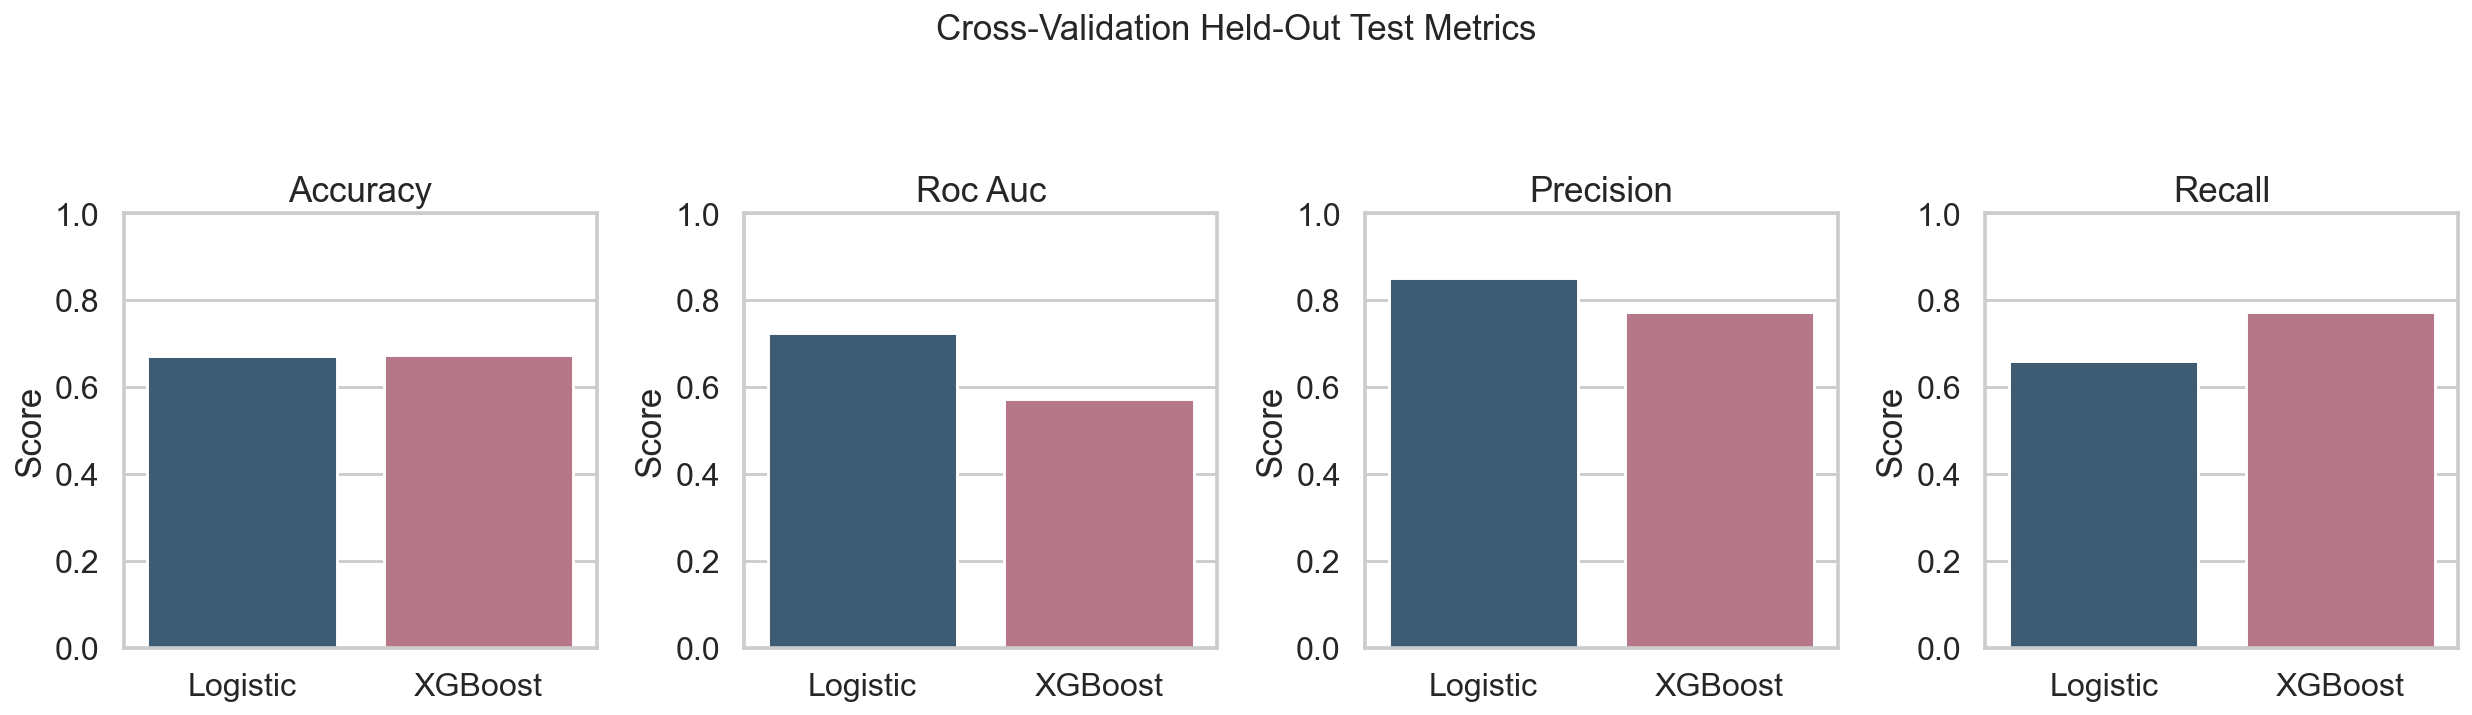

In [6]:
metric_order = ["accuracy", "roc_auc", "precision", "recall"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))

for ax, metric in zip(axes, metric_order):
    sns.barplot(
        data=crossval_test,
        x="model",
        y=metric,
        hue="model",
        palette=MODEL_COLORS,
        legend=False,
        ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)

fig.suptitle("Cross-Validation Held-Out Test Metrics", y=1.08, fontsize=18)
plt.tight_layout()
save_current_figure("cross_validation_test_metrics.png")
plt.show()


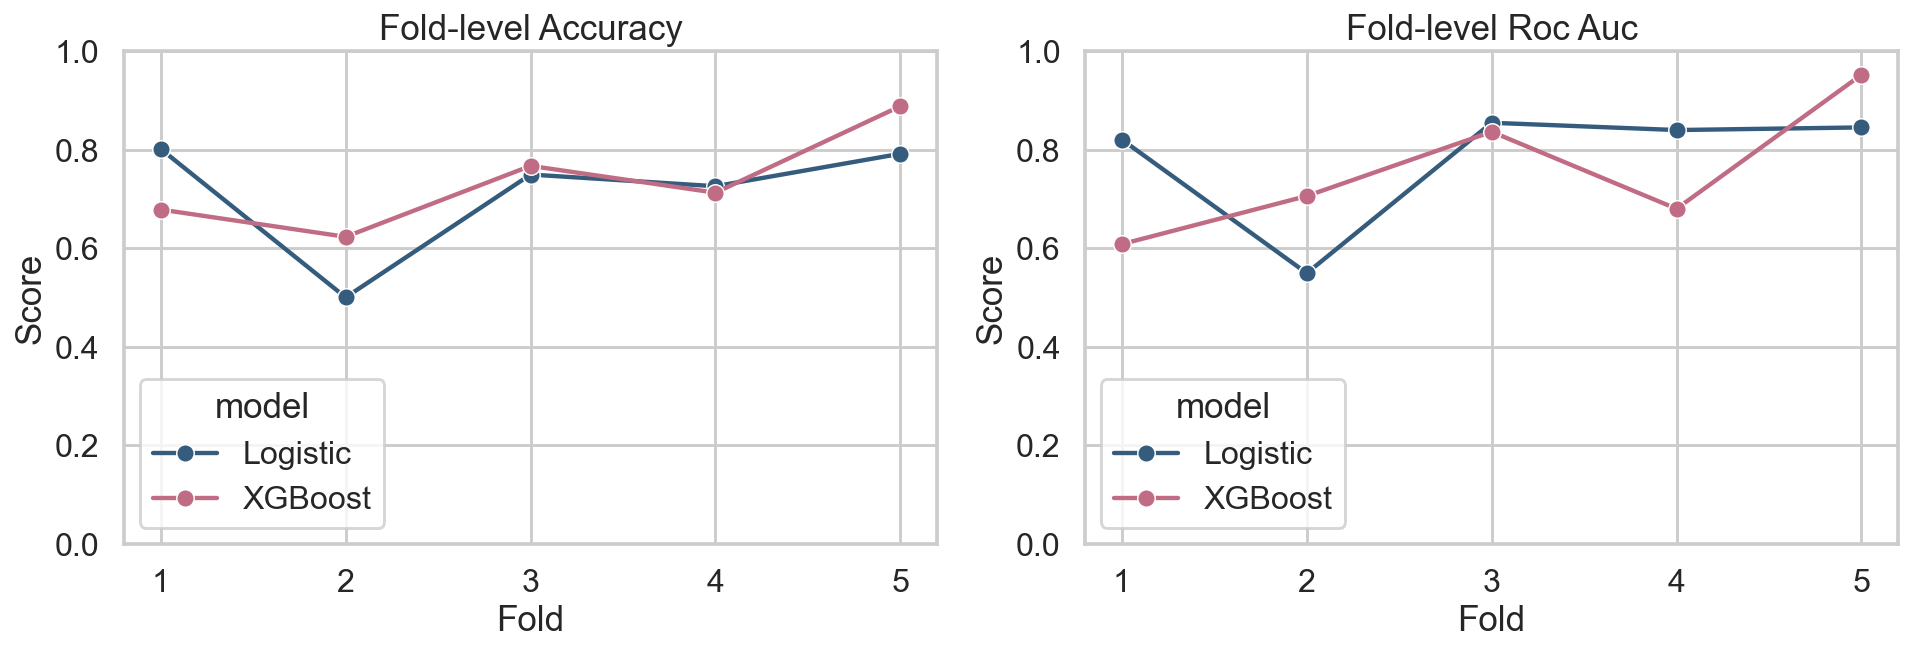

In [7]:
fold_only = crossval_folds[crossval_folds["row_type"] == "fold"].copy()
fold_only["fold"] = fold_only["fold"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, metric in zip(axes, ["accuracy", "roc_auc"]):
    sns.lineplot(
        data=fold_only,
        x="fold",
        y=metric,
        hue="model",
        marker="o",
        palette=MODEL_COLORS,
        ax=ax,
    )
    ax.set_title(f"Fold-level {metric.replace('_', ' ').title()}")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)

plt.tight_layout()
save_current_figure("cross_validation_fold_metrics.png")
plt.show()


## 1-Day Feature Signal Views

For the linear and tree baselines, the exported coefficients and feature importances are useful static views to pair with the model metrics.


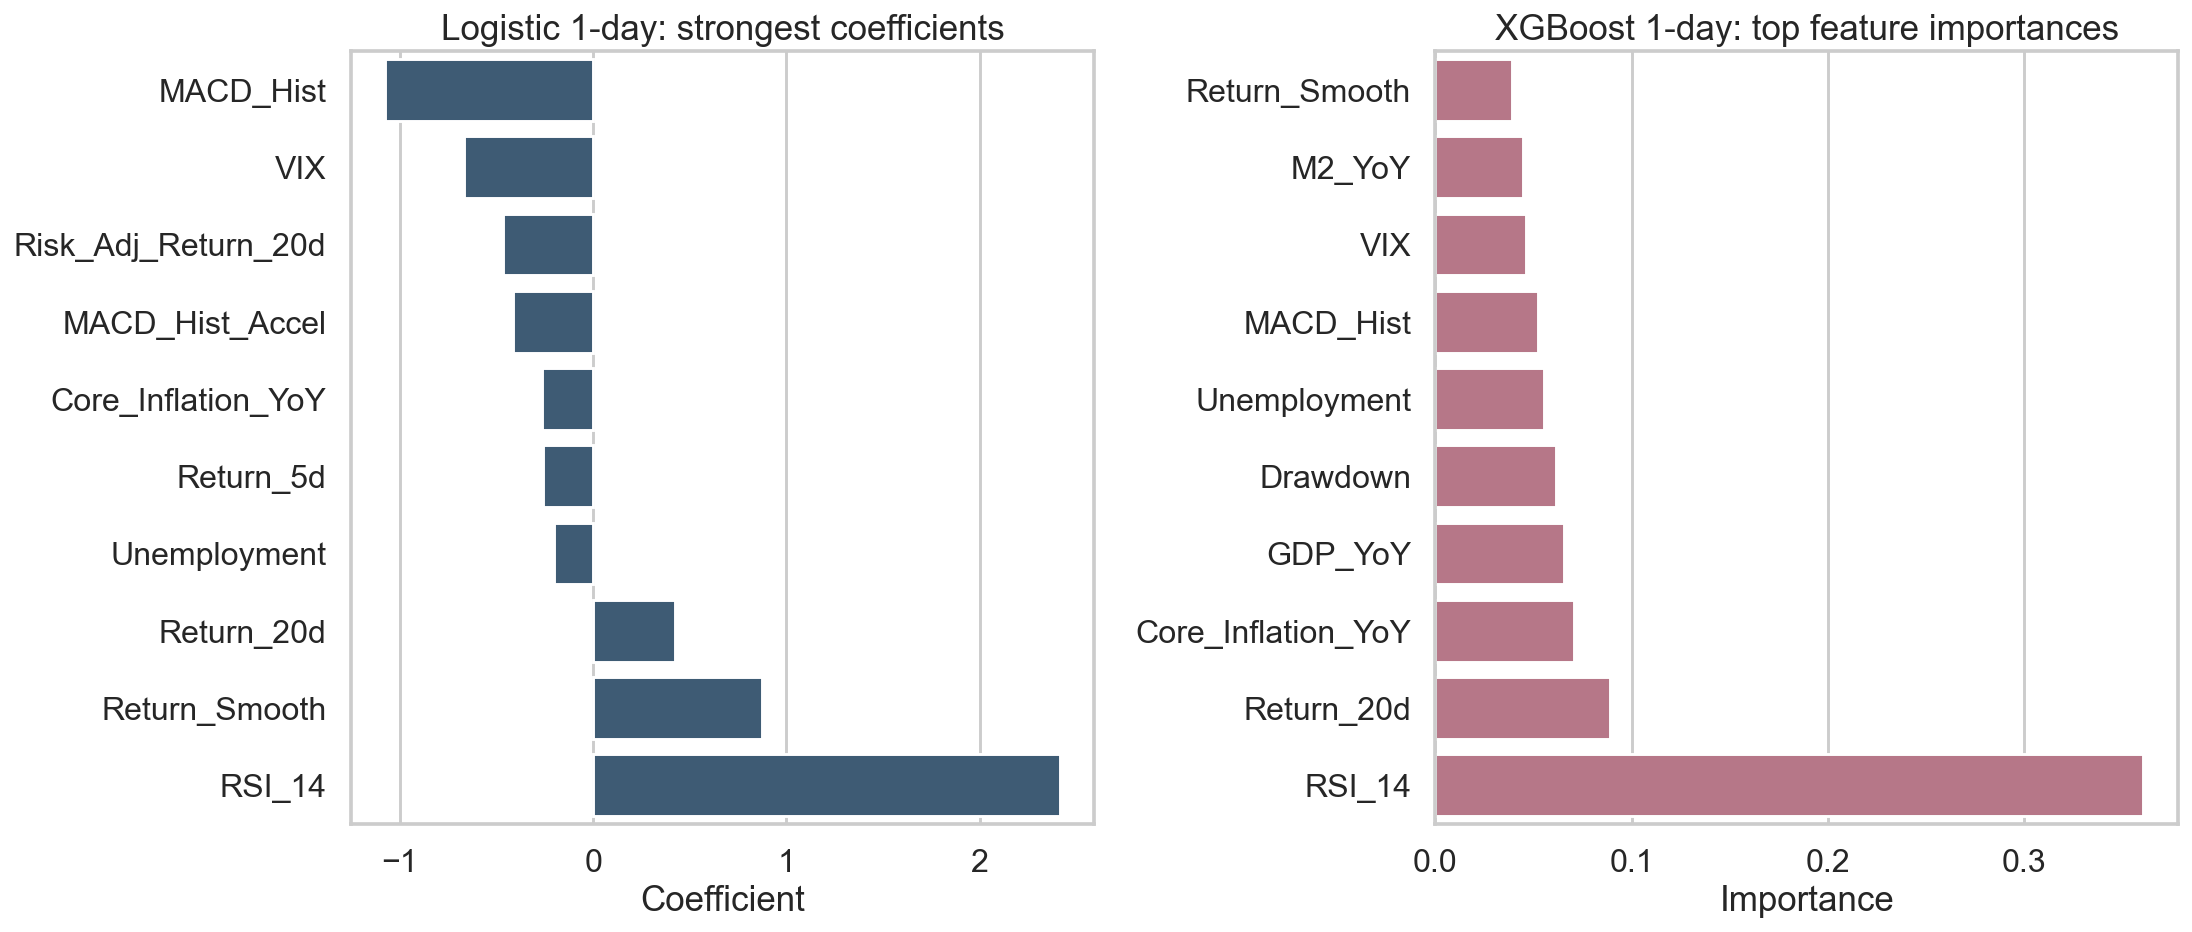

In [8]:
logistic_coef = pd.read_csv(REPORTS_DIR / "trained_logistic" / "basecase_1day" / "coefficients.csv")
logistic_coef = logistic_coef[logistic_coef["feature"] != "const"].copy()
logistic_coef["abs_coefficient"] = logistic_coef["coefficient"].abs()
logistic_top = logistic_coef.nlargest(10, "abs_coefficient").sort_values("coefficient")

xgb_importance = pd.read_csv(REPORTS_DIR / "trained_xgboost" / "basecase_1day" / "feature_importance.csv")
xgb_top = xgb_importance.nlargest(10, "importance").sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(data=logistic_top, x="coefficient", y="feature", color=MODEL_COLORS["Logistic"], ax=axes[0])
axes[0].set_title("Logistic 1-day: strongest coefficients")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("")

sns.barplot(data=xgb_top, x="importance", y="feature", color=MODEL_COLORS["XGBoost"], ax=axes[1])
axes[1].set_title("XGBoost 1-day: top feature importances")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.tight_layout()
save_current_figure("model_signal_views_1day.png")
plt.show()


## Training Dynamics

The forecasting notebooks now export enough artifact data to compare how the tree and transformer-style models trained over time.


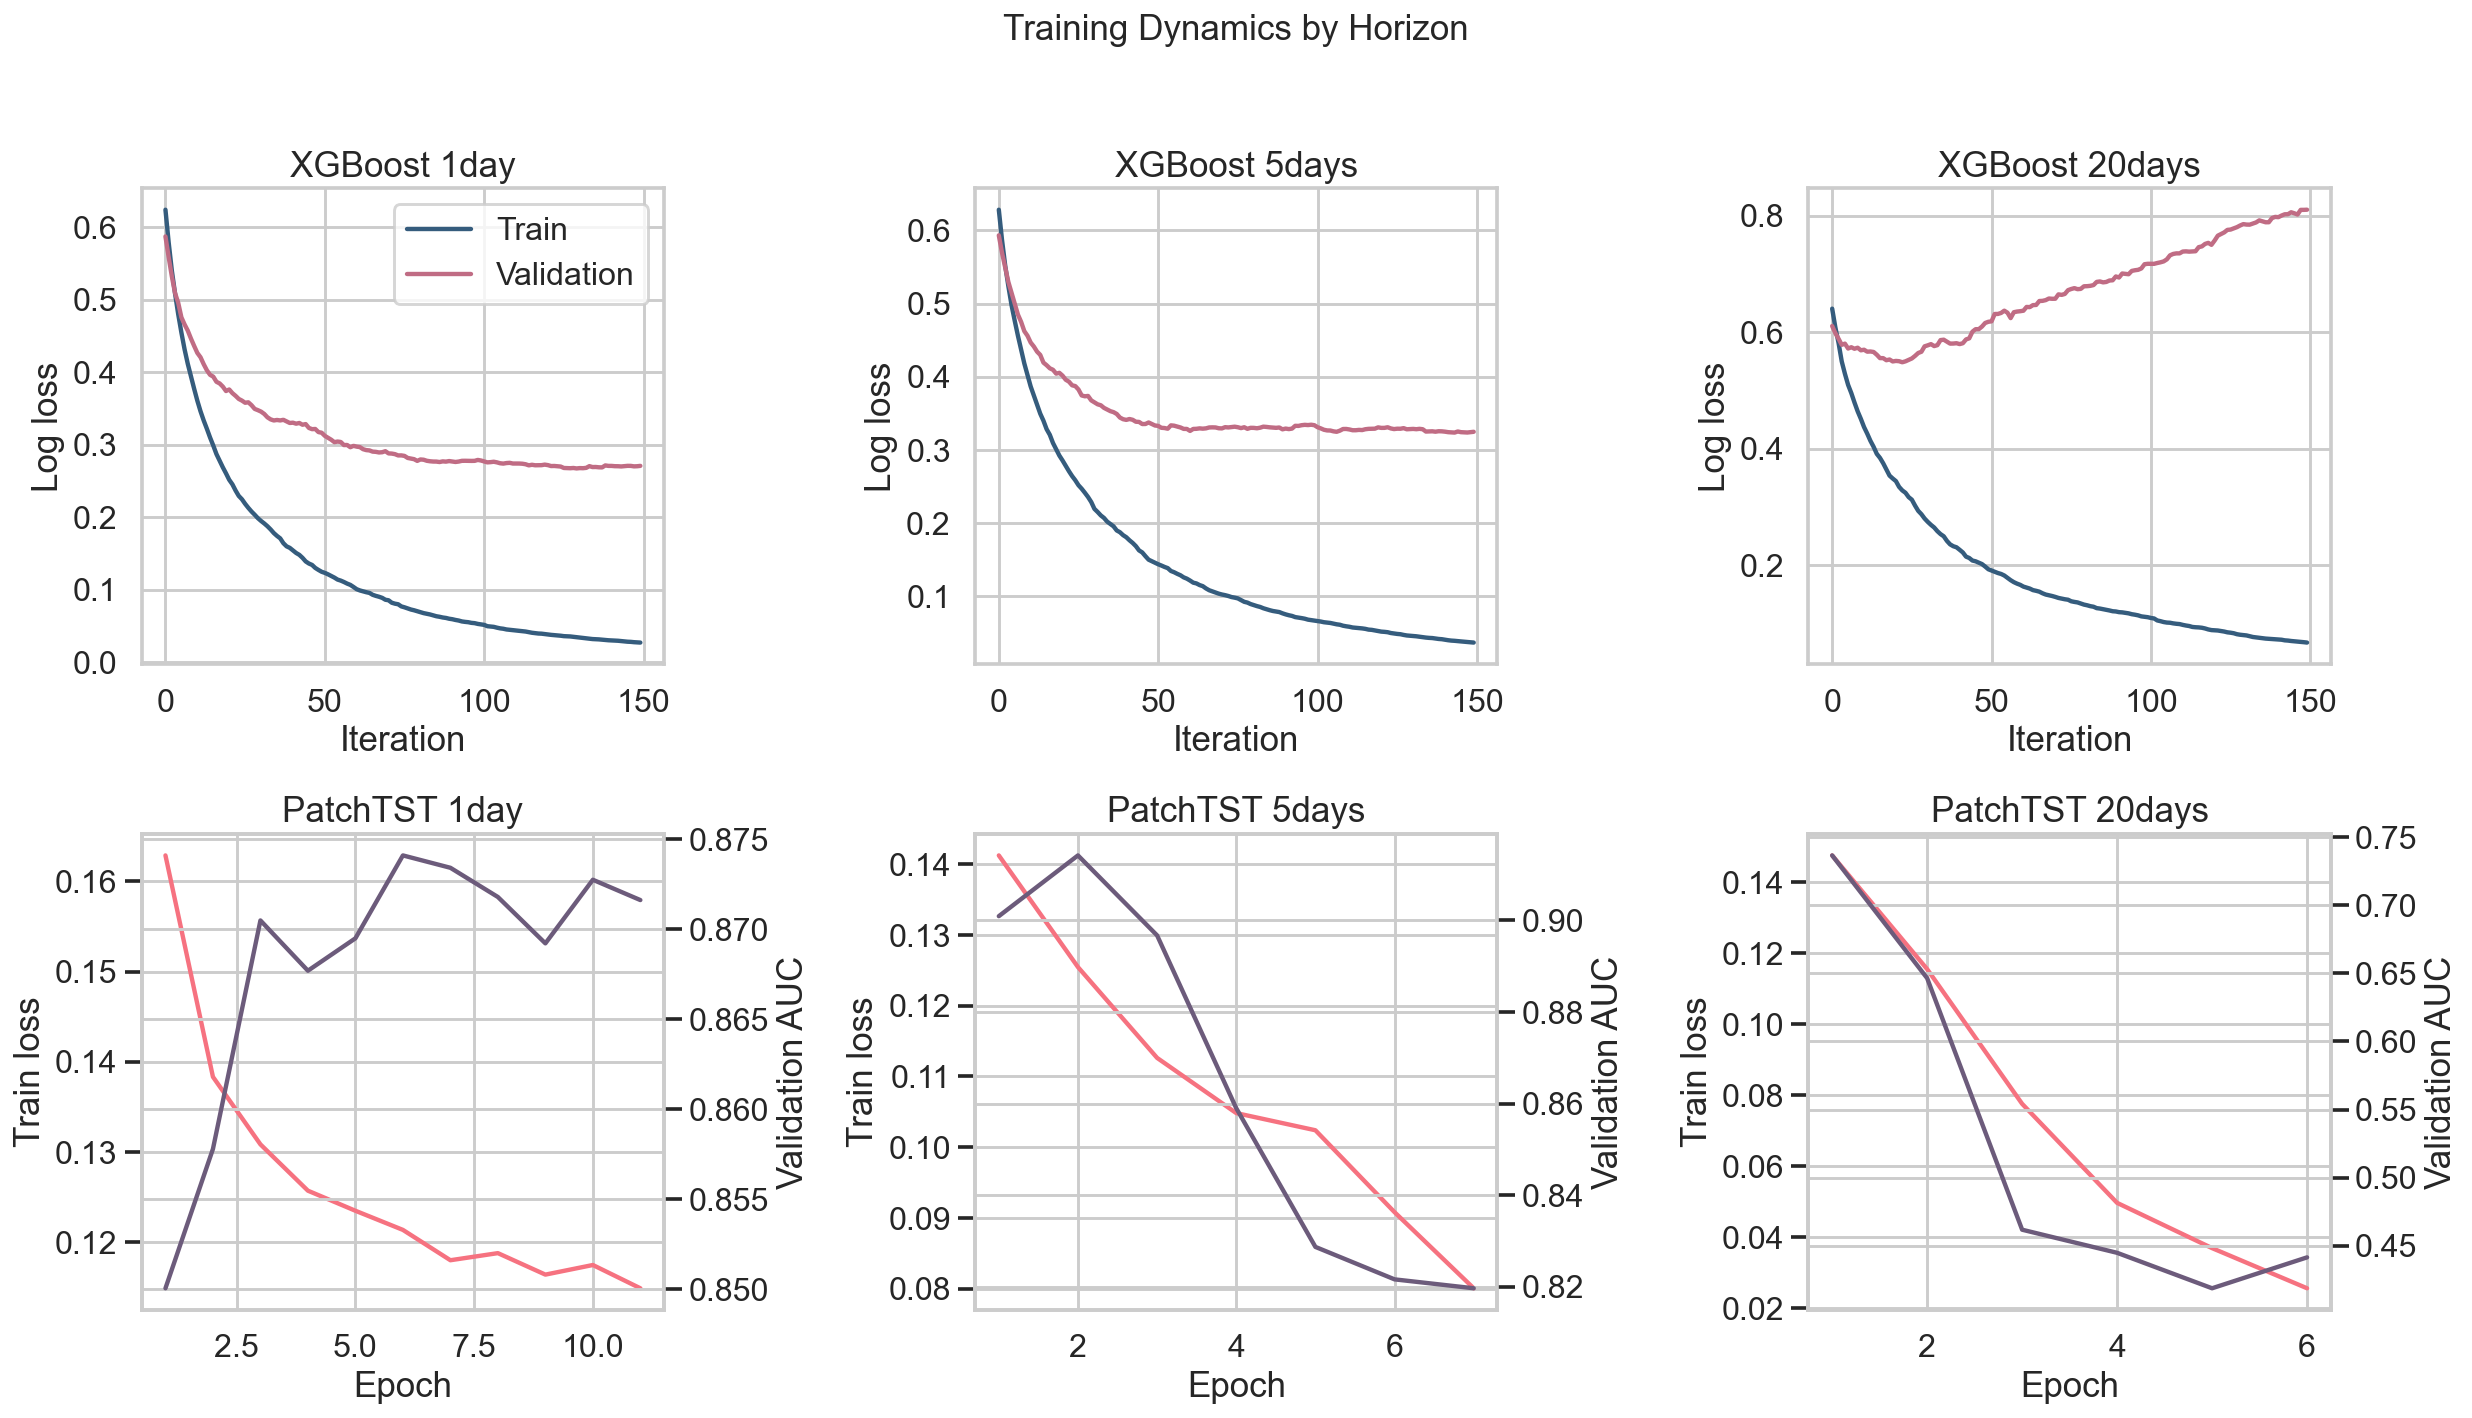

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, horizon in enumerate(["1day", "5days", "20days"]):
    xgb_df = xgb_learning_curves[xgb_learning_curves["horizon"] == horizon]
    patch_df = patchtst_training[patchtst_training["horizon"] == horizon]

    ax = axes[0, idx]
    ax.plot(xgb_df["iteration"], xgb_df["train_logloss"], label="Train", color="#355C7D")
    ax.plot(xgb_df["iteration"], xgb_df["val_logloss"], label="Validation", color="#C06C84")
    ax.set_title(f"XGBoost {horizon}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Log loss")
    if idx == 0:
        ax.legend()

    ax = axes[1, idx]
    ax.plot(patch_df["epoch"], patch_df["train_loss"], label="Train loss", color="#F67280")
    ax2 = ax.twinx()
    ax2.plot(patch_df["epoch"], patch_df["val_auc"], label="Validation AUC", color="#6C5B7B")
    ax.set_title(f"PatchTST {horizon}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train loss")
    ax2.set_ylabel("Validation AUC")

fig.suptitle("Training Dynamics by Horizon", y=1.02, fontsize=18)
plt.tight_layout()
save_current_figure("training_dynamics.png")
plt.show()


## LSTM Summary

LSTM is kept separate because its exported horizons are `1day`, `5days`, and `30days`, and it currently ships metrics/PNG artifacts rather than prediction-level CSVs.


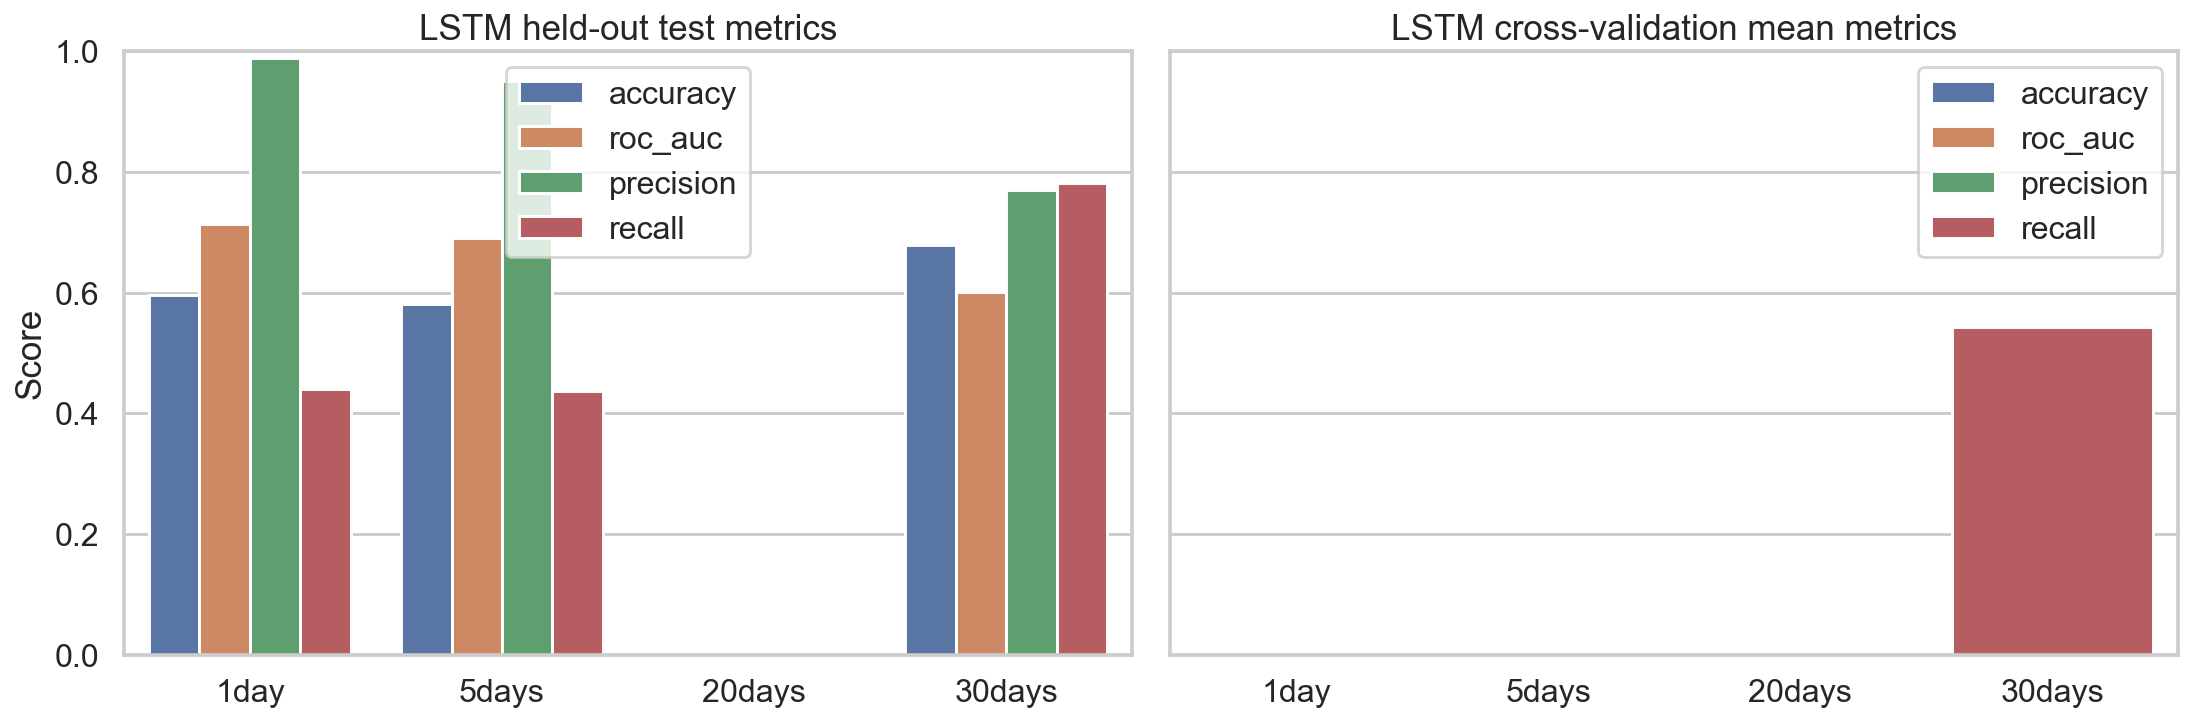

In [10]:
cv_mean = lstm_cv.iloc[[-2]].copy()
cv_mean["fold"] = "Mean"
cv_mean["horizon"] = pd.Categorical(cv_mean["horizon"], categories=HORIZON_ORDER, ordered=True)

test_long = lstm_test.melt(
    id_vars=["model", "split", "horizon", "split_name"],
    value_vars=["accuracy", "roc_auc", "precision", "recall"],
    var_name="metric",
    value_name="value",
)
cv_long = cv_mean.melt(
    id_vars=["model", "horizon", "fold"],
    value_vars=["accuracy", "roc_auc", "precision", "recall"],
    var_name="metric",
    value_name="value",
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
sns.barplot(data=test_long, x="horizon", y="value", hue="metric", ax=axes[0])
axes[0].set_title("LSTM held-out test metrics")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.0)

sns.barplot(data=cv_long, x="horizon", y="value", hue="metric", ax=axes[1])
axes[1].set_title("LSTM cross-validation mean metrics")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].set_ylim(0, 1.0)

axes[1].legend(title="")
axes[0].legend(title="")
plt.tight_layout()
save_current_figure("lstm_metric_summary.png")
plt.show()


## Saved Artifact Galleries

These grids reuse the exported PNGs so the report notebook can quickly surface the original single-model diagnostics without rerunning training.


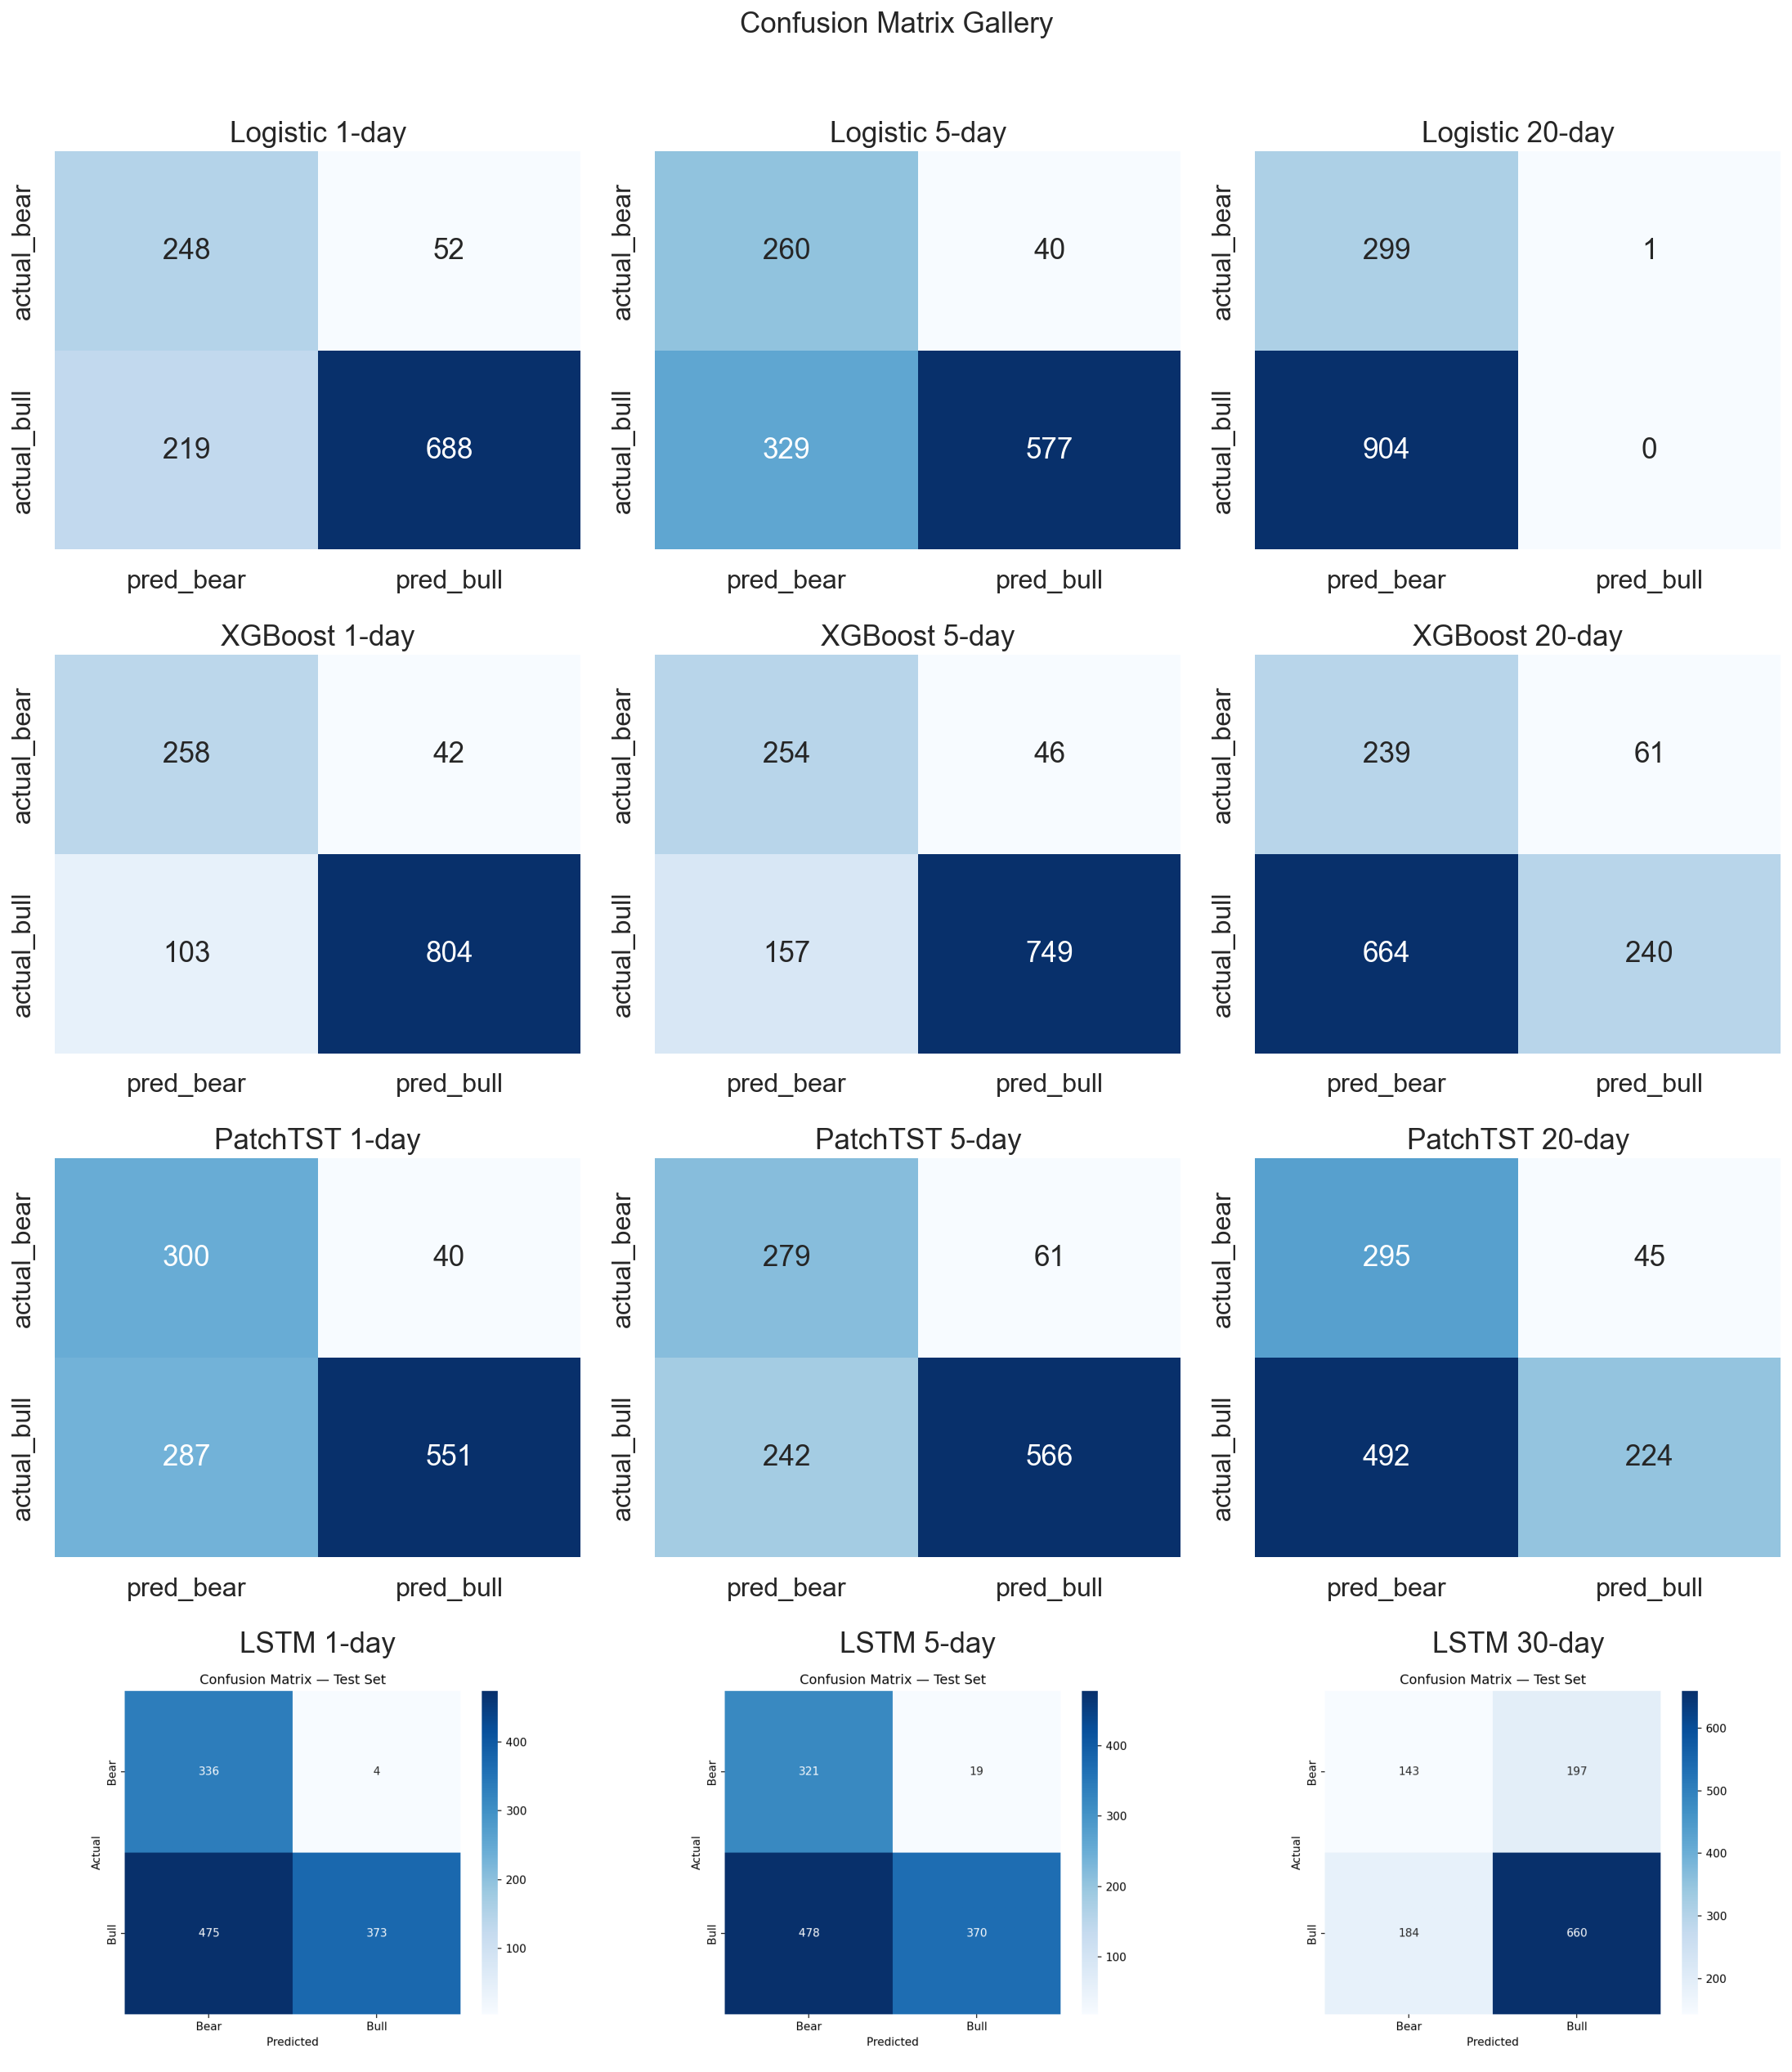

In [11]:
confusion_specs = [
    ("Logistic 1-day", REPORTS_DIR / "trained_logistic" / "basecase_1day" / "confusion_matrix.csv", None),
    ("Logistic 5-day", REPORTS_DIR / "trained_logistic" / "basecase_5days" / "confusion_matrix.csv", None),
    ("Logistic 20-day", REPORTS_DIR / "trained_logistic" / "basecase_20days" / "confusion_matrix.csv", None),
    ("XGBoost 1-day", REPORTS_DIR / "trained_xgboost" / "basecase_1day" / "confusion_matrix.csv", None),
    ("XGBoost 5-day", REPORTS_DIR / "trained_xgboost" / "basecase_5days" / "confusion_matrix.csv", None),
    ("XGBoost 20-day", REPORTS_DIR / "trained_xgboost" / "basecase_20days" / "confusion_matrix.csv", None),
    ("PatchTST 1-day", REPORTS_DIR / "trained_patchtst" / "results_lag_1" / "confusion_matrix.csv", None),
    ("PatchTST 5-day", REPORTS_DIR / "trained_patchtst" / "results_lag_5" / "confusion_matrix.csv", None),
    ("PatchTST 20-day", REPORTS_DIR / "trained_patchtst" / "results_lag_20" / "confusion_matrix.csv", None),
    ("LSTM 1-day", None, REPORTS_DIR / "trained_ltsm" / "results_lag_1" / "confusion_matrix.png"),
    ("LSTM 5-day", None, REPORTS_DIR / "trained_ltsm" / "results_lag_5" / "confusion_matrix.png"),
    ("LSTM 30-day", None, REPORTS_DIR / "trained_ltsm" / "results_lag_30" / "confusion_matrix.png"),
]

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
for ax, (title, csv_path, image_path) in zip(axes.ravel(), confusion_specs):
    draw_confusion_artifact(ax, title, csv_path=csv_path, image_path=image_path)

plt.suptitle("Confusion Matrix Gallery", y=1.01, fontsize=18)
plt.tight_layout()
save_current_figure("confusion_matrix_gallery.png")
plt.show()


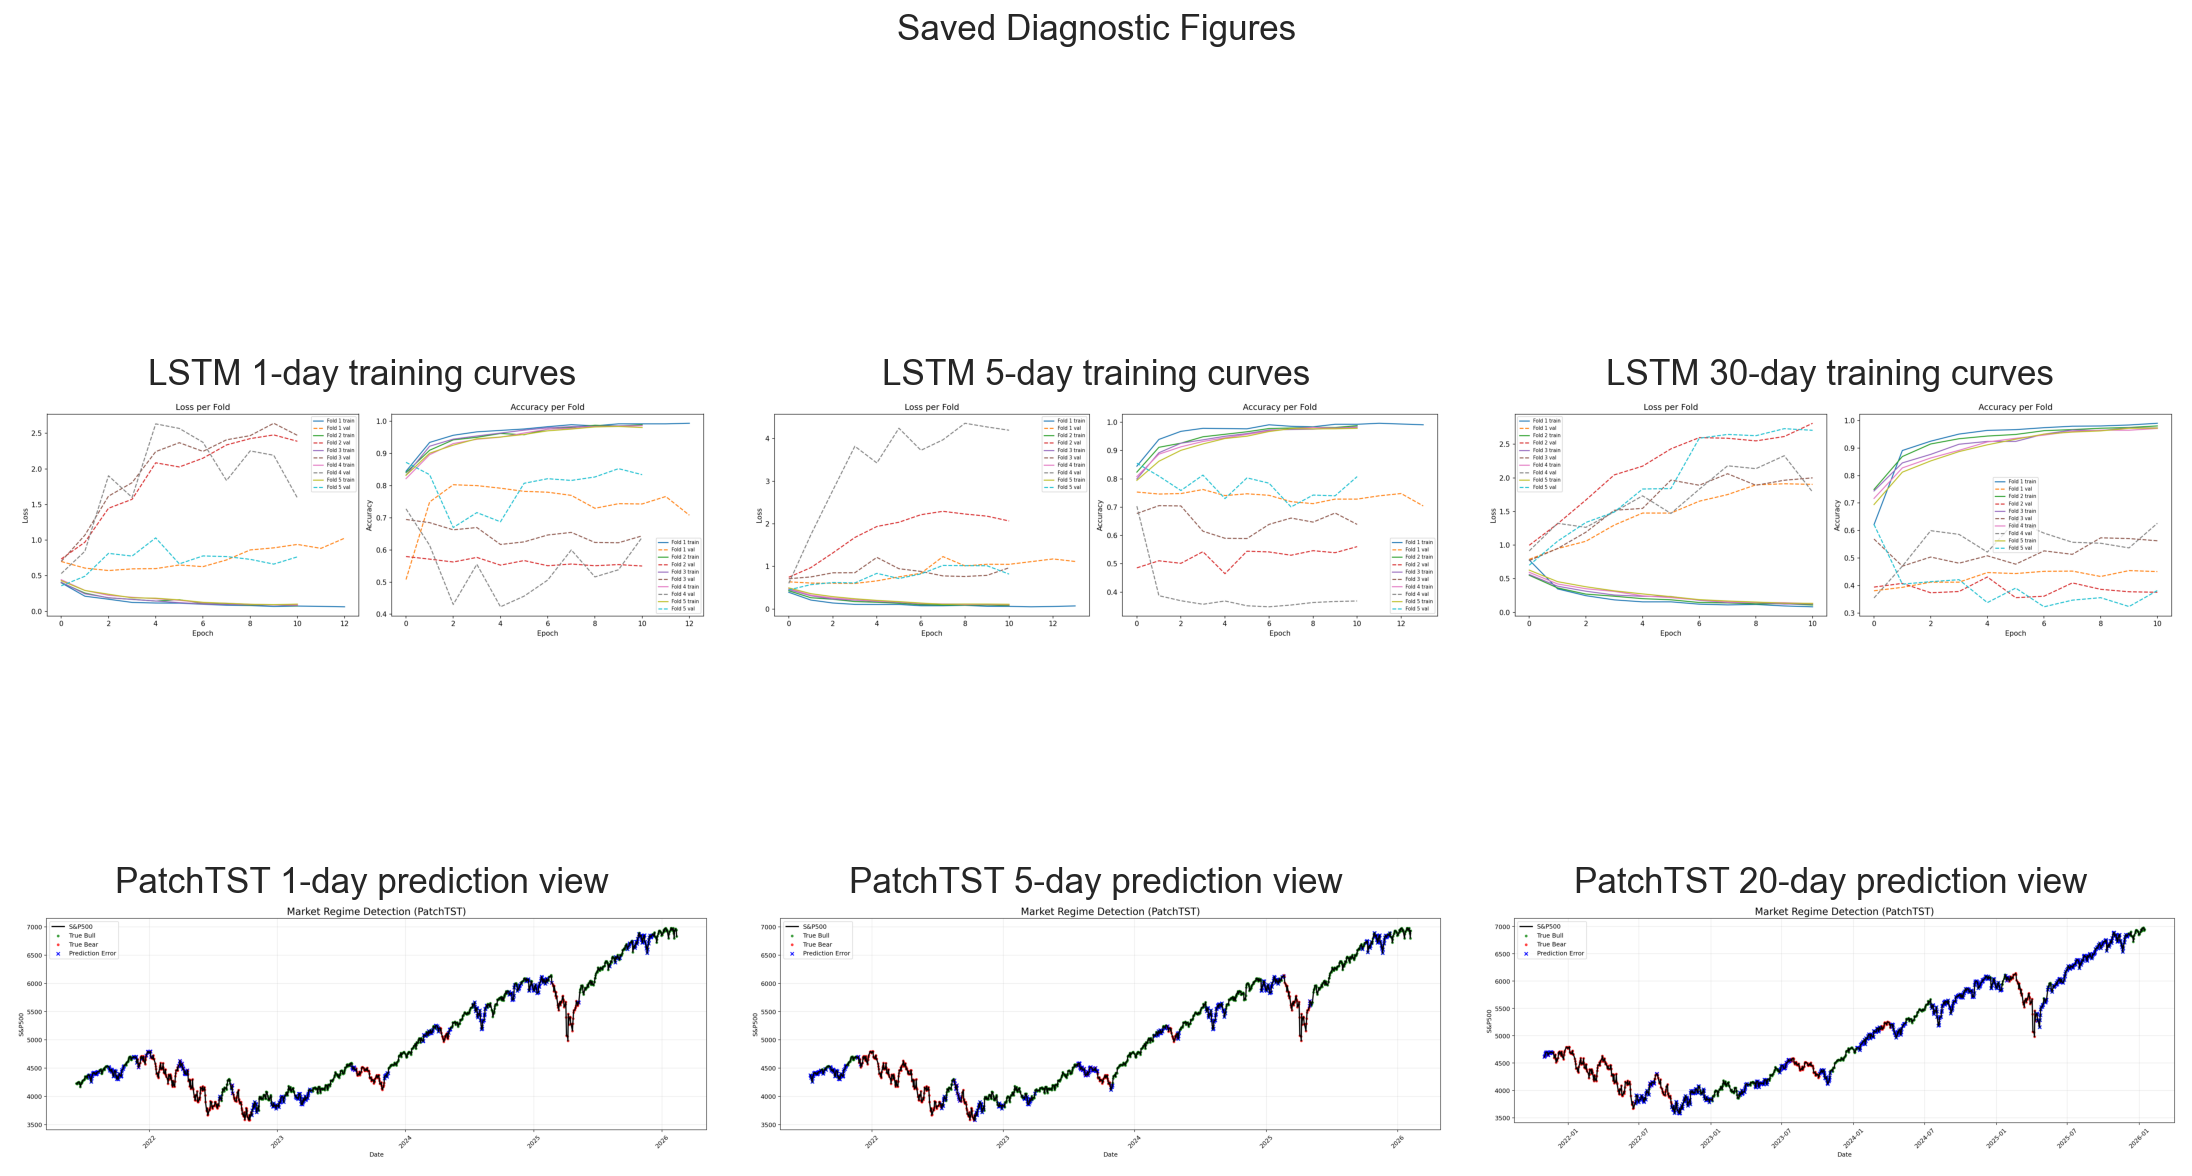

In [12]:
lstm_curve_paths = [
    REPORTS_DIR / "trained_ltsm" / "results_lag_1" / "training_curves.png",
    REPORTS_DIR / "trained_ltsm" / "results_lag_5" / "training_curves.png",
    REPORTS_DIR / "trained_ltsm" / "results_lag_30" / "training_curves.png",
    REPORTS_DIR / "trained_patchtst" / "results_lag_1" / "prediction_visualisation.png",
    REPORTS_DIR / "trained_patchtst" / "results_lag_5" / "prediction_visualisation.png",
    REPORTS_DIR / "trained_patchtst" / "results_lag_20" / "prediction_visualisation.png",
]
lstm_curve_titles = [
    "LSTM 1-day training curves",
    "LSTM 5-day training curves",
    "LSTM 30-day training curves",
    "PatchTST 1-day prediction view",
    "PatchTST 5-day prediction view",
    "PatchTST 20-day prediction view",
]

plot_image_grid(lstm_curve_paths, lstm_curve_titles, ncols=3, figsize=(16, 10))
plt.suptitle("Saved Diagnostic Figures", y=1.02, fontsize=18)
plt.tight_layout()
save_current_figure("saved_diagnostic_gallery.png")
plt.show()
